In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import os

# =====================================================
# Load all datasets
# =====================================================
print("Loading datasets...")

# Old weighted dataset (Disease–Symptom mapping)
df = pd.read_csv("data/dataset.csv")  
severity_df = pd.read_csv("data/Symptom-severity.csv")  
desc_df = pd.read_csv("data/symptom_Description.csv")  
precaution_df = pd.read_csv("data/symptom_precaution.csv")

# New binary dataset (1/0 symptom encoding)
new_df = pd.read_csv("data/dataset2.csv")   

print("Datasets loaded successfully.")


Loading datasets...
Datasets loaded successfully.


In [2]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
severity_df.head()

,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


In [4]:
new_df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
desc_df.head()

,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...


In [4]:
precaution_df.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [5]:
# =====================================================
# Process the old weighted dataset
# =====================================================
symptom_cols = [col for col in df.columns if col.startswith("Symptom_")]
for col in symptom_cols:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

severity_df["Symptom"] = severity_df["Symptom"].astype(str).str.strip().str.capitalize()
unique_symptoms = list(set(severity_df["Symptom"]))
severity_dict = dict(zip(severity_df["Symptom"], severity_df["weight"]))

X_weighted = pd.DataFrame(0, index=df.index, columns=unique_symptoms, dtype=float)
y_weighted = df["Disease"]

for idx, row in df.iterrows():
    for col in symptom_cols:
        sym = row[col]
        if sym != "nan" and sym in X_weighted.columns:
            X_weighted.at[idx, sym] = severity_dict.get(sym, 1)


In [6]:
# =====================================================
# Process the new binary dataset
# =====================================================
print("Processing binary dataset...")

disease_col = "diseases"  # change this if named differently
X_binary = new_df.drop(columns=[disease_col])
y_binary = new_df[disease_col]

# Align columns with symptom names from weighted dataset
# (merge both to create a unified feature space)
all_symptoms = sorted(list(set(X_binary.columns) | set(unique_symptoms)))

# Add missing columns filled with 0 to both datasets
for col in all_symptoms:
    if col not in X_weighted.columns:
        X_weighted[col] = 0
    if col not in X_binary.columns:
        X_binary[col] = 0

# Reorder columns
X_weighted = X_weighted[all_symptoms]
X_binary = X_binary[all_symptoms]

Processing binary dataset...


C:\Users\15197\AppData\Local\Temp\ipykernel_2028\896470106.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_binary[col] = 0
C:\Users\15197\AppData\Local\Temp\ipykernel_2028\896470106.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_binary[col] = 0
C:\Users\15197\AppData\Local\Temp\ipykernel_2028\896470106.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) 

In [7]:
# =====================================================
# Combine both datasets
# =====================================================
all_symptoms = sorted(set(X_weighted.columns) | set(X_binary.columns))

# Reindex datasets to same columns
X_weighted = X_weighted.reindex(columns=all_symptoms, fill_value=0)
X_binary = X_binary.reindex(columns=all_symptoms, fill_value=0)

X_combined = pd.concat([X_weighted, X_binary], ignore_index=True)
y_combined = pd.concat([y_weighted, y_binary], ignore_index=True)

print(f"Combined dataset shape: {X_combined.shape}")
print(f"Total unique diseases: {len(y_combined.unique())}")

Combined dataset shape: (251865, 509)
Total unique diseases: 814


In [8]:
all_symptoms

['Abdominal_pain',
 'Abnormal_menstruation',
 'Acidity',
 'Acute_liver_failure',
 'Altered_sensorium',
 'Anxiety',
 'Back_pain',
 'Belly_pain',
 'Blackheads',
 'Bladder_discomfort',
 'Blister',
 'Blood_in_sputum',
 'Bloody_stool',
 'Blurred_and_distorted_vision',
 'Breathlessness',
 'Brittle_nails',
 'Bruising',
 'Burning_micturition',
 'Chest_pain',
 'Chills',
 'Cold_hands_and_feets',
 'Coma',
 'Congestion',
 'Constipation',
 'Continuous_feel_of_urine',
 'Continuous_sneezing',
 'Cough',
 'Cramps',
 'Dark_urine',
 'Dehydration',
 'Depression',
 'Diarrhoea',
 'Dischromic_patches',
 'Distention_of_abdomen',
 'Dizziness',
 'Drying_and_tingling_lips',
 'Enlarged_thyroid',
 'Excessive_hunger',
 'Extra_marital_contacts',
 'Family_history',
 'Fast_heart_rate',
 'Fatigue',
 'Fluid_overload',
 'Foul_smell_ofurine',
 'Headache',
 'High_fever',
 'Hip_joint_pain',
 'History_of_alcohol_consumption',
 'Increased_appetite',
 'Indigestion',
 'Inflammatory_nails',
 'Internal_itching',
 'Irregular_sugar

In [ ]:
# =====================================================
# Memory-safe sampling before training
# =====================================================
print("\n Sampling dataset for memory efficiency...")
X_sample = X_combined.sample(frac=0.25, random_state=42)   # Using 25% of data
y_sample = y_combined.loc[X_sample.index]
print(f"Sampled dataset: {X_sample.shape}")


 Sampling dataset for memory efficiency...
Sampled dataset: (62966, 509)


In [10]:
# =====================================================
# Train/Test Split
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)


In [11]:
# =====================================================
# Training Models and predicting accuracy
# =====================================================
models={
    "Random Forest":RandomForestClassifier(n_estimators=50, random_state=42),
    "Naive Bayes":GaussianNB(),
    "Decision Tree":DecisionTreeClassifier(random_state=42)
}
predictions={}
for name,model in models.items():
    print(f"Training {name}...")
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    print(f"Accuracy:{acc:.4f}")
    predictions[name]=pred

Training Random Forest...
Accuracy:0.8427
Training Naive Bayes...
Accuracy:0.8694
Training Decision Tree...
Accuracy:0.7731


           Model  Accuracy
0  Random Forest  0.842703
1    Naive Bayes  0.869382
2  Decision Tree  0.773067


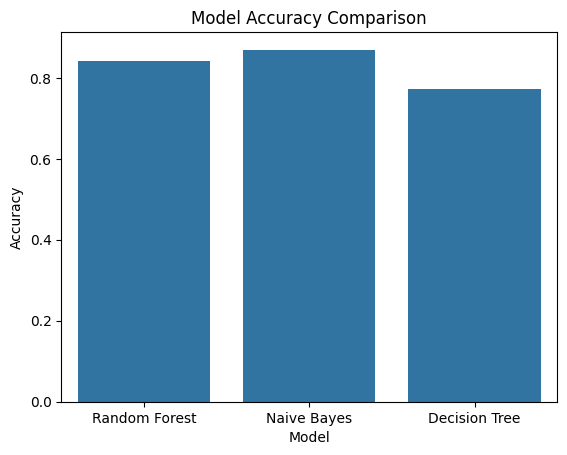

In [ ]:
# =====================================================
# Model Accuracy Comparison
# =====================================================
accuracy_table = pd.DataFrame({
    "Model": list(models.keys()),
    "Accuracy": [accuracy_score(y_test, predictions[name]) for name in models]
})

print(accuracy_table)
sns.barplot(data=accuracy_table, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
# =====================================================
# Calculating Precision, Recall and F1 score
# =====================================================
def prf_summary(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Metrics ---")
    print("Precision:", precision_score(y_true, y_pred, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, average='weighted', zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted', zero_division=0))

for name, pred in predictions.items():
    prf_summary(y_test, pred, name)


--- Random Forest Metrics ---
Precision: 0.8485410024695346
Recall: 0.8427028743846277
F1 Score: 0.8423805210134411

--- Naive Bayes Metrics ---
Precision: 0.8944510157838784
Recall: 0.8693822455137367
F1 Score: 0.8725660596260247

--- Decision Tree Metrics ---
Precision: 0.7877107432829232
Recall: 0.7730665396220422
F1 Score: 0.7751735547931177


In [17]:
# =====================================================
# Ensemble Voting
# =====================================================

# Create voting matrix (samples x models)
voting_matrix = np.array([predictions[m] for m in models]).T  # shape: (n_samples, n_models)

# Majority vote for each sample
majority_votes = [Counter(row).most_common(1)[0][0] for row in voting_matrix]

# Ensemble metrics
ensemble_acc = accuracy_score(y_test, majority_votes)
ensemble_precision = precision_score(y_test, majority_votes, average='weighted', zero_division=0)
ensemble_recall = recall_score(y_test, majority_votes, average='weighted', zero_division=0)
ensemble_f1 = f1_score(y_test, majority_votes, average='weighted', zero_division=0)

print(f"\n Ensemble Metrics (Majority Voting)")
print(f"Accuracy : {ensemble_acc:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall   : {ensemble_recall:.4f}")
print(f"F1 Score : {ensemble_f1:.4f}")



 Ensemble Metrics (Majority Voting)
Accuracy : 0.8491
Precision: 0.8554
Recall   : 0.8491
F1 Score : 0.8490


In [18]:
# =====================================================
# Prediction function
# =====================================================
def predict_disease_with_explanation(user_symptoms):
    user_symptoms = [sym.strip().capitalize() for sym in user_symptoms]
    input_vector = pd.Series(0, index=all_symptoms, dtype=float)

    for sym in user_symptoms:
        if sym in input_vector.index:
            input_vector[sym] = severity_dict.get(sym, 1)

    if input_vector.sum() == 0:
        return {
            "disease": "Unknown",
            "model_predictions": {},
            "description": "No matching symptoms found.",
            "precautions": "Cannot suggest precautions."
        }

    input_data = pd.DataFrame([input_vector], columns=all_symptoms)

    model_preds = {name: str(model.predict(input_data)[0]) for name, model in models.items()}
    predicted_disease = Counter(model_preds.values()).most_common(1)[0][0]

    desc_row = desc_df[desc_df["Disease"] == predicted_disease]
    description = desc_row["Description"].values[0] if not desc_row.empty else "No description available."

    precaution_cols = ["Precaution_1", "Precaution_2", "Precaution_3", "Precaution_4"]
    precaution_row = precaution_df[precaution_df["Disease"] == predicted_disease]
    if not precaution_row.empty:
        precaution_text = ", ".join(
            str(precaution_row[col].values[0])
            for col in precaution_cols if pd.notna(precaution_row[col].values[0])
        )
    else:
        precaution_text = "No precautions listed."

    return {
        "disease": predicted_disease,
        "model_predictions": model_preds,
        "description": description,
        "precautions": precaution_text
    }


def predict_disease_with_explanation_pretty(user_symptoms):
    result = predict_disease_with_explanation(user_symptoms)
    print("\n================ Disease Prediction =================\n")
    print(f"Disease Predicted: {result['disease']}\n")
    print("Model Prediction:")
    for model, pred in result["model_predictions"].items():
        print(f"    {model:<15}: {pred}")
    print()
    print("Description:")
    print(f"    {result['description']}\n")
    print("Precautions:")
    print(f"    {result['precautions']}")
    print("\n====================================================\n")



In [19]:
test_symptoms = ['stomach_pain', 'urination', 'Nausea']
result = predict_disease_with_explanation_pretty(test_symptoms)
print(result)


================ Disease Prediction =================

Disease Predicted: Drug Reaction

Model Prediction:
    Random Forest  : Drug Reaction
    Naive Bayes    : Drug Reaction
    Decision Tree  : Drug Reaction

Description:
    An adverse drug reaction (ADR) is an injury caused by taking medication. ADRs may occur following a single dose or prolonged administration of a drug or result from the combination of two or more drugs.

Precautions:
    stop irritation, consult nearest hospital, stop taking drug, follow up


None


In [20]:
test_symptoms2 = ['stomach_pain', 'acidity', 'ulcers_on_tongue']
result = predict_disease_with_explanation_pretty(test_symptoms2)
print(result)


================ Disease Prediction =================

Disease Predicted: GERD

Model Prediction:
    Random Forest  : GERD
    Naive Bayes    : Drug Reaction
    Decision Tree  : GERD

Description:
    Gastroesophageal reflux disease, or GERD, is a digestive disorder that affects the lower esophageal sphincter (LES), the ring of muscle between the esophagus and stomach. Many people, including pregnant women, suffer from heartburn or acid indigestion caused by GERD.

Precautions:
    avoid fatty spicy food, avoid lying down after eating, maintain healthy weight, exercise


None
